# US Cities Temperatures

### Created while following MIT 6.100L Course (online) and added some changes

#### Importing libraries

In [2]:
import matplotlib.pyplot as plt
import numpy as np

#### Change °C to °F

In [3]:
def CtoF(c):
    return (c * 9/5) + 32

#### Reading the data 

In [4]:
def getCities():
    cities = []
    with open('temperatures.csv', 'r') as f:
        for line in f:
            c = line.split(',')[0]
            if c not in cities:
                cities.append(c)
    return cities[1:]

In [5]:
def getTempsForCity(city):
    temps = []
    dates = []
    with open('temperatures.csv') as f:
        for line in f:
            items = line.split(',')
            if items[0].lower() == city.lower():
                temps.append(float(items[1]))
                dates.append(items[2].strip())
    return temps, dates

#### Exploring average temperatures

In [6]:
def getAverageTemps():
    cities = getCities()
    avgTemps = []
    cityLabels = []
    for city in cities:
        temps, _ = getTempsForCity(city)
        avgTemp = sum(temps) / len(temps)
        avgTemps.append(avgTemp)
        cityLabels.append(city[0:2])
    return avgTemps, cityLabels

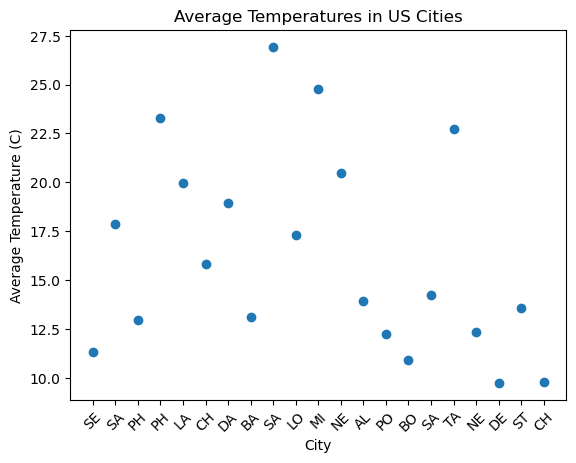

In [7]:
avgTempsC, cityLabels = getAverageTemps()
xPts = np.arange(len(cityLabels))
avgTempsC = np.array(avgTempsC)
plt.scatter(xPts, avgTempsC)
plt.title('Average Temperatures in US Cities')
plt.xlabel('City')
plt.ylabel('Average Temperature (C)')
plt.xticks(xPts, cityLabels, rotation=45)
plt.show()

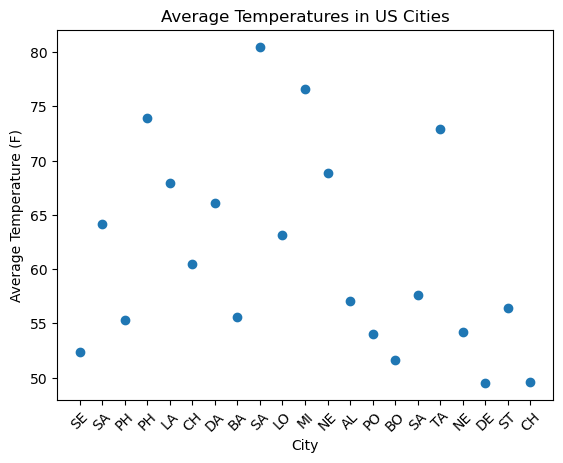

In [8]:
avgTempsF = CtoF(avgTempsC)
plt.scatter(xPts, avgTempsF)
plt.title('Average Temperatures in US Cities')
plt.xlabel('City')
plt.ylabel('Average Temperature (F)')
plt.xticks(xPts, cityLabels, rotation=45)
plt.show()

#### Get average temps by year by city

In [9]:
def getAvgTempForYear(temps, dates, year):
    yearlyTemps = []
    for i in range(len(temps)):
        if dates[i][0:4] == str(year):
            yearlyTemps.append(temps[i])
    return sum(yearlyTemps) / len(yearlyTemps)

In [10]:
def getTempsPerYearForCity(city):
    temps, dates = getTempsForCity(city)
    avgs = []
    years = []
    for i in range(1961, 2016):
        avgs.append(getAvgTempForYear(temps, dates, i))
        years.append(i)
    return avgs, years

#### Using subplots to display all cities in a grid

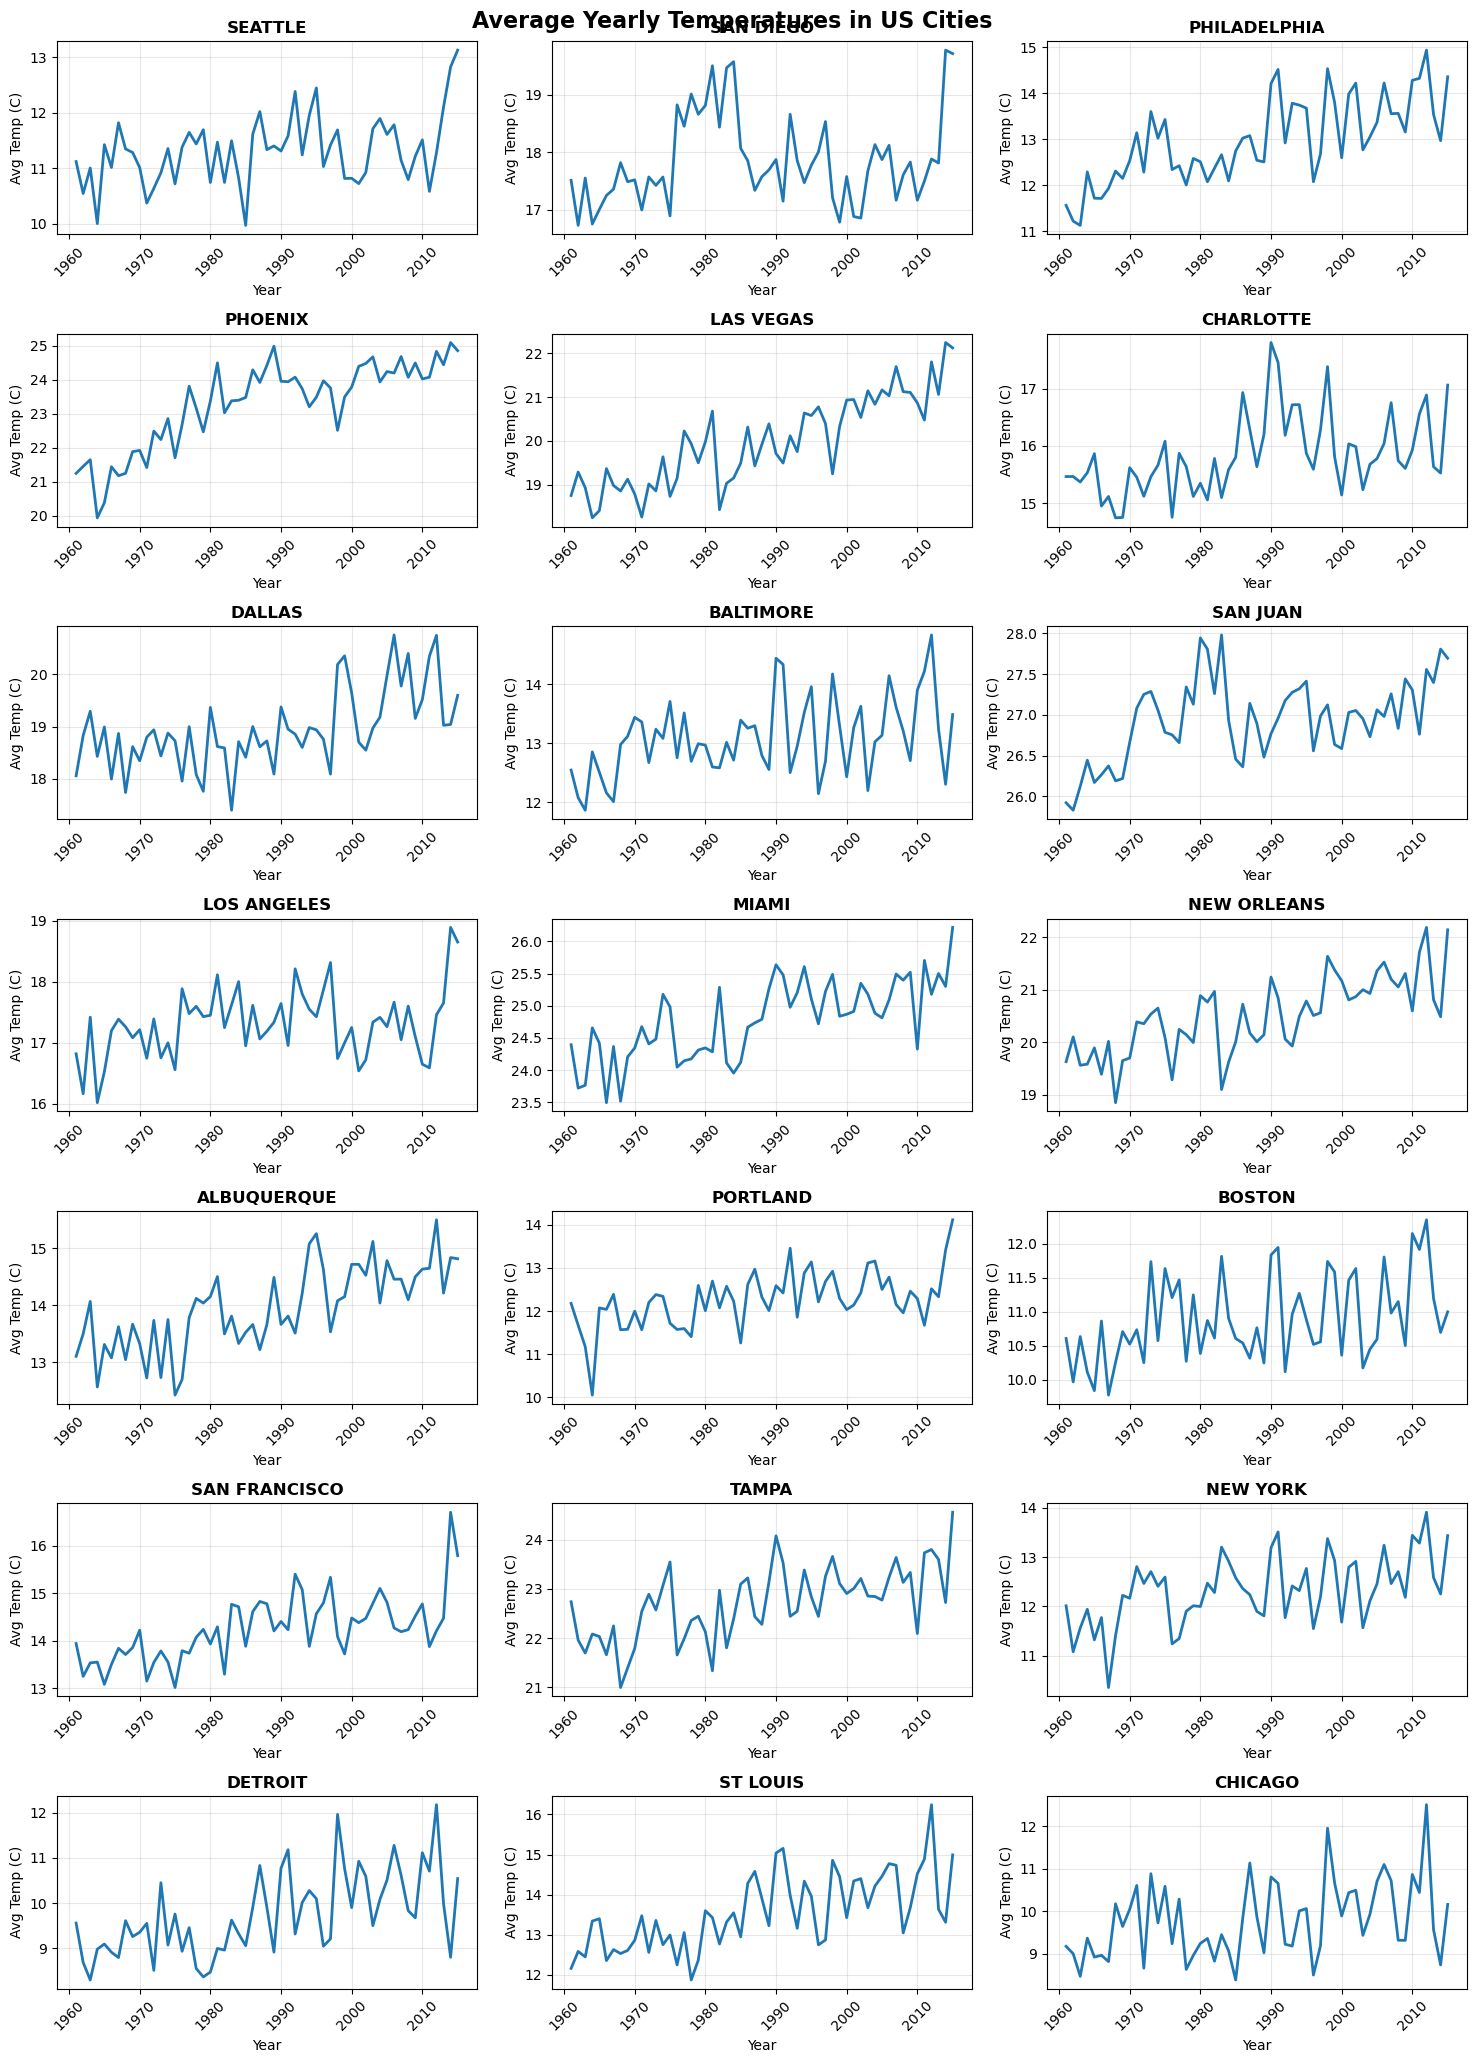

In [11]:
cities = getCities()
num_cities = len(cities)

# Calculate grid dimensions (e.g., 2 rows x 3 columns for 6 cities)
cols = 3
rows = (num_cities + cols - 1) // cols  # Ceiling division

plt.figure(figsize=(15, rows * 3))

for idx, city in enumerate(cities, 1):
    avgs, years = getTempsPerYearForCity(city)
    
    plt.subplot(rows, cols, idx)
    plt.plot(years, avgs, linewidth=2)
    plt.title(f'{city}', fontsize=12, fontweight='bold')
    plt.xlabel('Year', fontsize=10)
    plt.ylabel('Avg Temp (C)', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)

plt.suptitle('Average Yearly Temperatures in US Cities', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

#### Get yearly average temperature for a city, including temperature range

In [12]:
def getTempsForYearRange(tem, dat, y):
    yearly = []
    for i in range(len(tem)):
        if y == dat[i][:4]:
            yearly.append(tem[i])
    return sum(yearly)/len(yearly), max(yearly), min(yearly)

In [13]:
def getTempsByYearForCityRange(city, start=1961, end=2015):
    temps, dates = getTempsForCity(city)
    averages = []
    maxes = []
    mins = []
    years = []
    for y in range(start, end + 1):
        tem, mx, mn = getTempsForYearRange(temps, dates, str(y))
        averages.append(tem)
        maxes.append(mx)
        mins.append(mn)
        years.append(y)
    return averages, maxes, mins, years

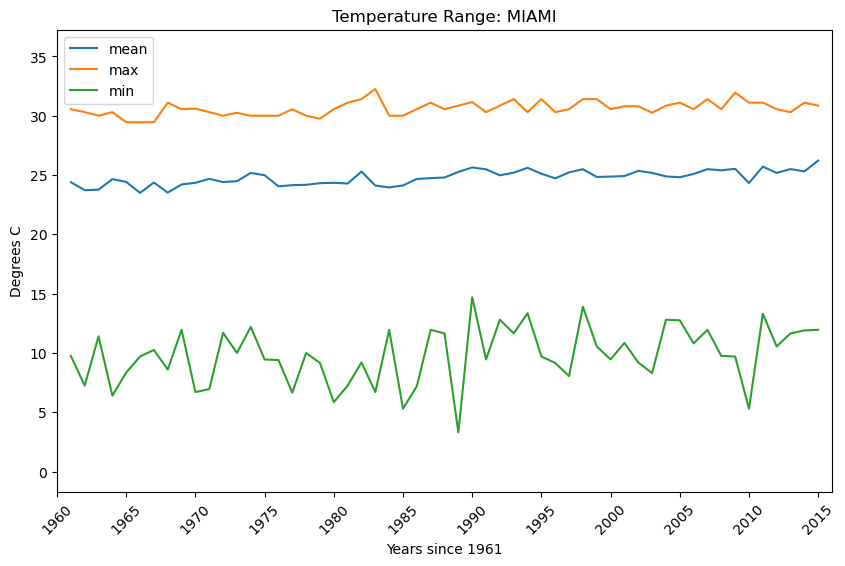

In [14]:
c = 'MIAMI'
av, mx, mn, yr = getTempsByYearForCityRange(c, start=1961, end=2015)
plt.figure(figsize=(10, 6))
plt.xlim(1960, 2016)  # Set x-axis limits with some padding
plt.ylim(min(mn) - 5, max(mx) + 5)  # Set y-axis limits with padding
plt.plot(yr, av, label = 'mean')
plt.plot(yr, mx, label = 'max')
plt.plot(yr, mn, label = 'min')        
plt.title('Temperature Range: ' + c)
plt.xlabel('Years since 1961')
plt.ylabel(('Degrees C'))
plt.xticks(range(1960, 2016, 5), rotation=45) # Generate ticks every 5 years from 1960 to 2020
plt.legend(loc = 'best')
plt.show()

#### Make temperature (in F) distributions

In [15]:
def getDayDistributionForCity(city, year):
    # assume a range of temperatures from 0 to 100
    tempsC, dates = getTempsForCity(city)
    tempsF = [CtoF(t) for t in tempsC]
    newTemps = []
    for i in range(len(dates)):
        if year == dates[i][:4]:
            newTemps.append(tempsF[i])
    ## want to map temperature to number of occurences
    d = [0]*100
    for t in newTemps:
        tRound = round(t)
        d[tRound] += 1
    return d

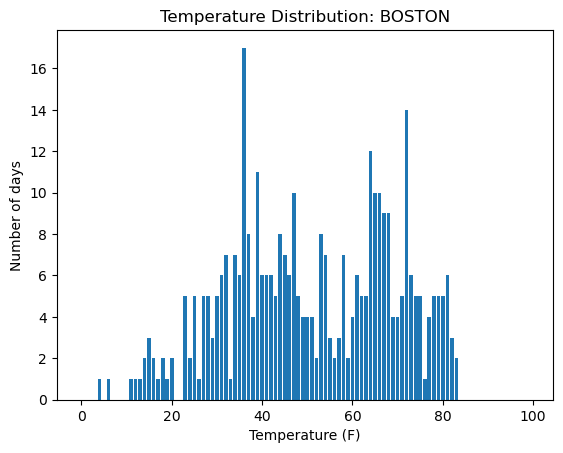

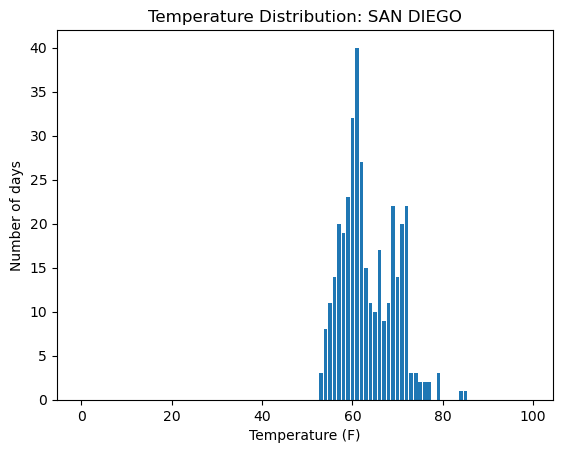

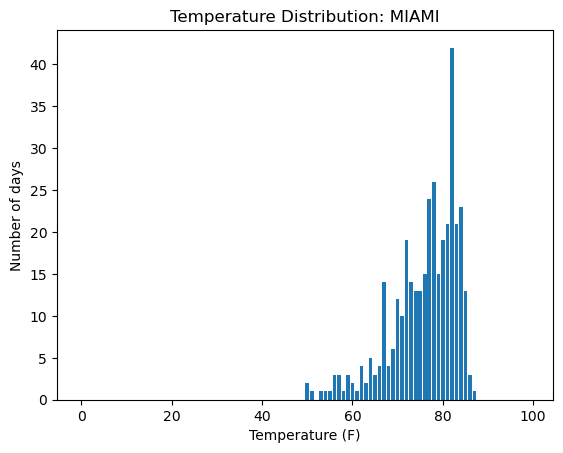

In [16]:
for c in ('BOSTON','SAN DIEGO', 'MIAMI'):  # try for BOSTON, SAN DIEGO, MIAMI
    ans = getDayDistributionForCity(c, '1961')
    temps = []
    for i in range(100):
        temps.append(i)
    plt.figure('Distribution of Temps by City: '+c)
    plt.bar(temps, ans)

    plt.title('Temperature Distribution: ' + c)
    plt.xlabel('Temperature (F)')
    plt.ylabel(('Number of days'))

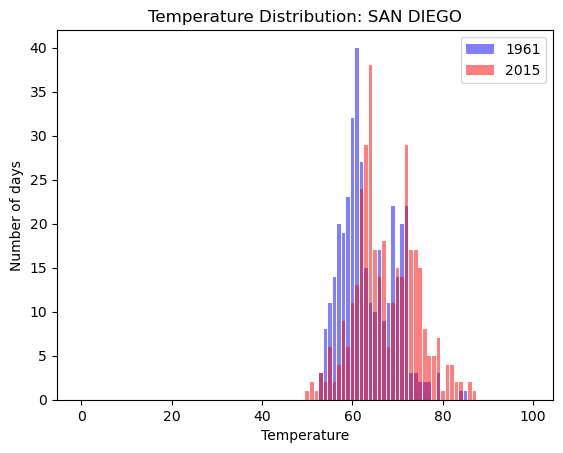

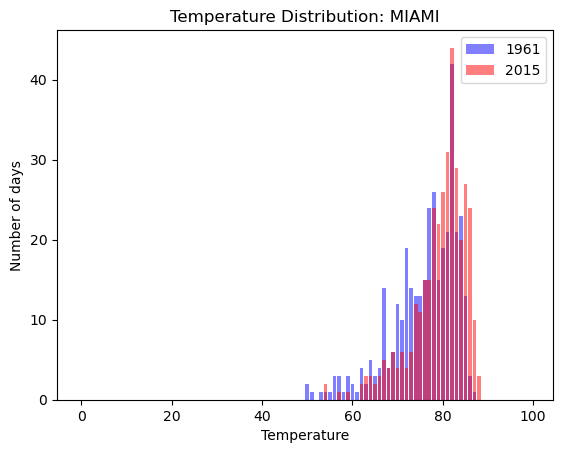

In [17]:
for c in ('SAN DIEGO', 'MIAMI'):
    plt.figure('Distribution of Temps by City')
    for y in ('1961','2015'):
        ans = getDayDistributionForCity(c, y)
        temps = []
        for i in range(100):
            temps.append(i)
        if y == '1961':
            plt.bar(temps, ans, color = 'blue', label = y, alpha=0.5)
        else:
            plt.bar(temps, ans, color = 'red', label = y, alpha=0.5)
    
    plt.title('Temperature Distribution: ' + c)
    plt.xlabel('Temperature')
    plt.ylabel(('Number of days'))
    plt.legend(loc = 'best')
    plt.show()

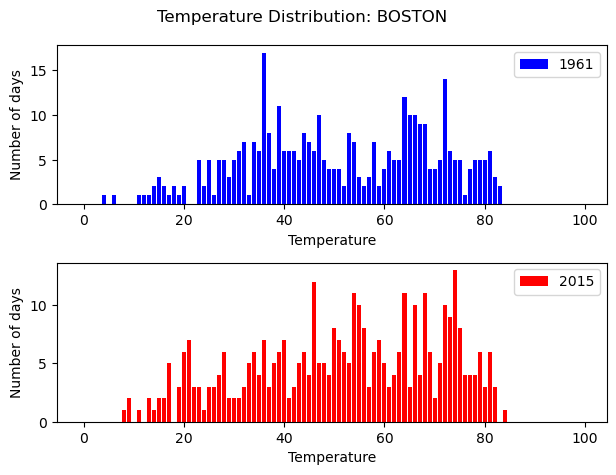

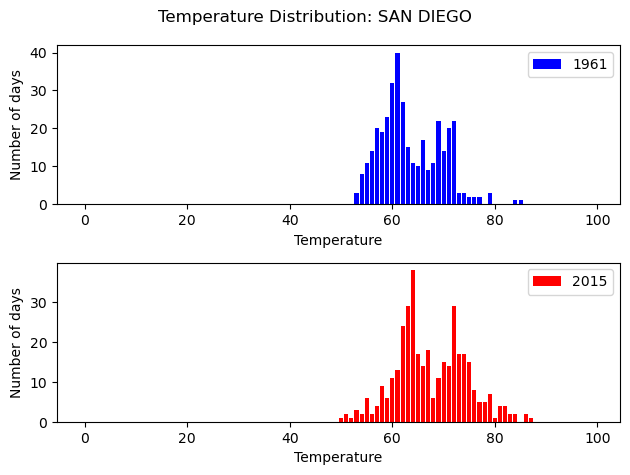

In [18]:
for c in ('BOSTON', 'SAN DIEGO'):
    plt.figure('Distribution of Temps by City')
    for y in ('1961', '2015'):
        ans = getDayDistributionForCity(c, y)
        temps = []
        for i in range(100):
            temps.append(i)
        if y == '1961':
            plt.subplot(2,1,1)
            plt.xlabel('Temperature')
            plt.ylabel(('Number of days'))
            plt.bar(temps, ans, color = 'blue', label = y)
        else:
            plt.subplot(2,1,2)
            plt.xlabel('Temperature')
            plt.ylabel(('Number of days'))
            plt.bar(temps, ans, color = 'red', label = y)
        plt.legend(loc = 'best')
    plt.suptitle('Temperature Distribution: ' + c)
    plt.tight_layout()
    plt.show()